# Superstore Sales Analysis
Exploratory Data Analysis of Superstore dataset using Python.

## Project Overview

The objective of this project is to analyze the Superstore dataset
to understand sales performance, profitability, customer segments,
and product trends.

**The analysis focuses on:**


*   Sales performancem
*   Profitability patterns
*   Regional performance
*   Product category analysis
*   Discount impact on profit
*   Customer purchasing behavior



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Load Dataset**

In [3]:

df = pd.read_csv("/content/Sample - Superstore.csv", encoding='cp1252')  #

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Check dataset info**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.shape

(9994, 21)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

***Data Cleaning***

**Convert date columns**

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

**Check missing values**

In [8]:
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


The dataset have no missing values

In [9]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


**Feature Engineering**

Create Order Year

In [10]:
df['Order Year'] = df['Order Date'].dt.year

Create Order Month

In [11]:
df['Order Month'] = df['Order Date'].dt.month

**Dataset Summary**

In [12]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Order Month
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654


**Total Sales, Profit, Quantity**

In [13]:
df[['Sales','Profit','Quantity']].sum()

,0
Sales,2.297201e+06
Profit,2.863970e+05
Quantity,3.787300e+04


**Sales by Category**

In [14]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


**Profit by Category**

In [15]:
df.groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


**Sales by Region**

In [16]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


**Top 10 Products by Sales**

In [17]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


**Profit by Sub Category**

In [18]:
df.groupby('Sub-Category')['Profit'].sum().sort_values()

,Profit
Sub-Category,
Tables,-17725.4811
Bookcases,-3472.5560
Supplies,-1189.0995
Fasteners,949.5182
Machines,3384.7569
Labels,5546.2540
Art,6527.7870
Envelopes,6964.1767
Furnishings,13059.1436


#Data Visualization

**Sales by Category**

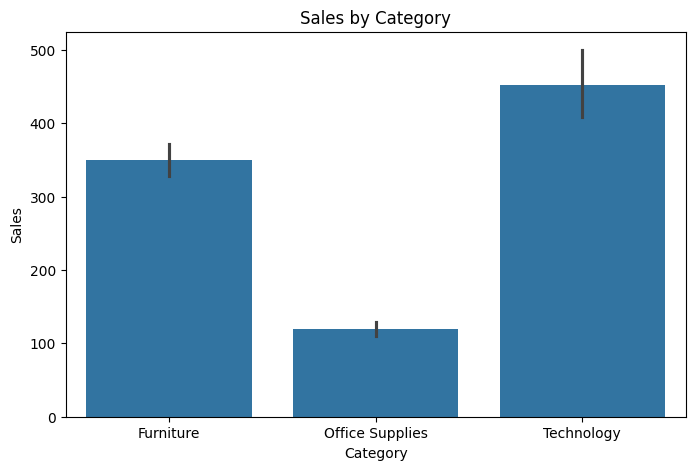

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

### Insights

Technology category generates the highest sales compared
to Furniture and Office Supplies.
#




**Profit by Category**

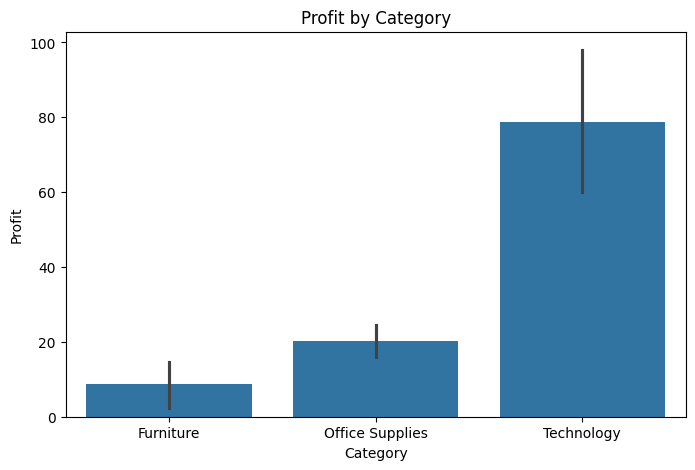

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Profit', data=df)
plt.title("Profit by Category")
plt.show()

**Insights**

Technology generates highest profit

Furniture has lower profitability
#
#



**Sales by Region**

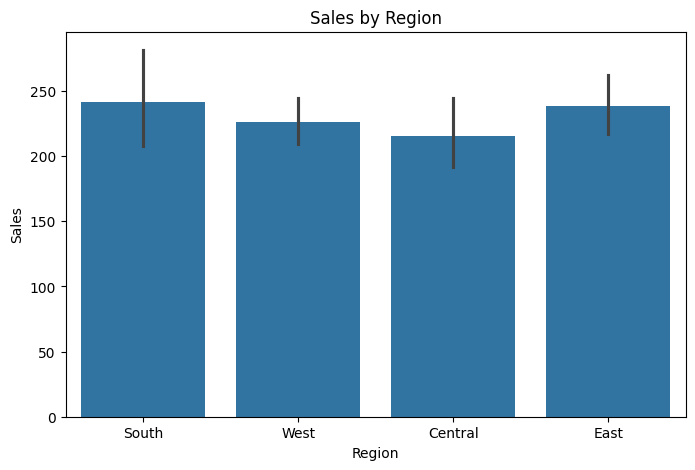

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=df)
plt.title("Sales by Region")
plt.show()

**Insight**

- South region shows the highest average sales (~$242), followed by East (~$238).
- Central region records the lowest average sales (~$216).
- Recommendation: Investigate the Central region to identify factors limiting sales and improve regional marketing strategies.
#

**Top 10 Sub-Categories by Sales**

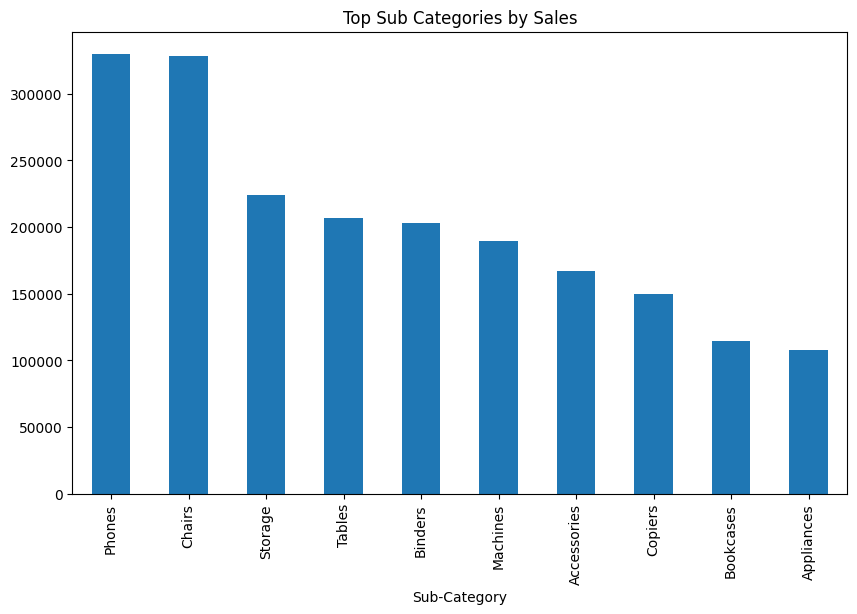

In [22]:
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_sub.plot(kind='bar')
plt.title("Top Sub Categories by Sales")
plt.show()

**Insights**

Phones is the top-selling
sub-category with the highest sales

Chairs and Storage are the second and third highest performing sub-categories

Appliances has the lowest sales among all sub-categories
#

**Monthly Sales Trend**

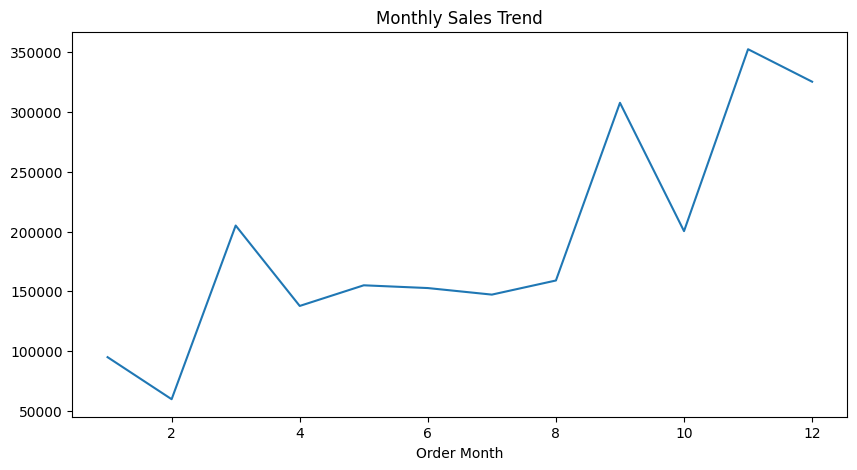

In [23]:
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

**Insights**

Sales peak in November and December, reaching the highest point around 350,000

Lowest sales occur in February, dropping to approximately 150,000

Overall upward trend from February through December with some fluctuations in between

#

**Profit vs Discount**

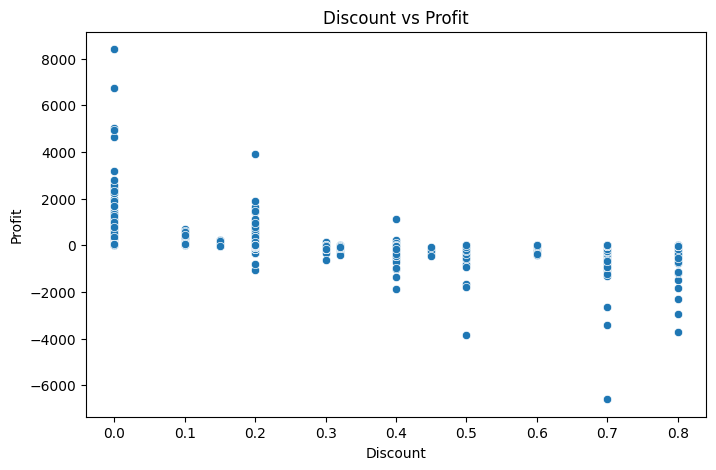

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

**Insights**

- Higher discounts are often associated with lower or negative profit.
- Orders with discounts above 30% frequently lead to losses.
- Recommendation: Implement stricter discount policies to protect profit margins.
#

**Correlation Heatmap**

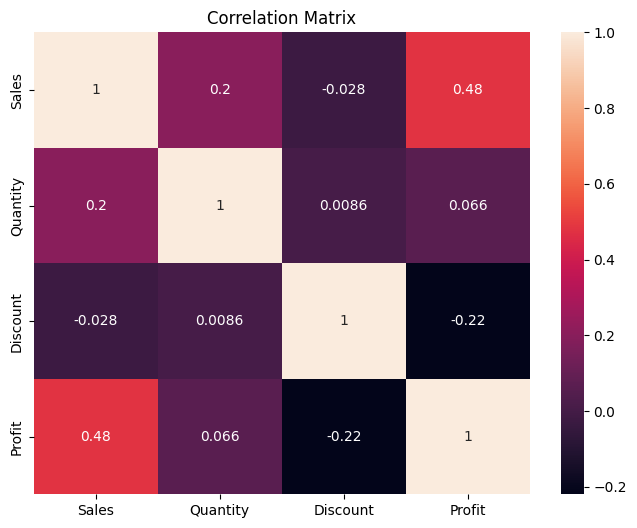

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Quantity','Discount','Profit']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

**Insights**

Sales and Profit have a moderate positive correlation (0.48), indicating higher sales tend to lead to higher profits

Discount and Profit have a negative correlation (-0.22), confirming that increased discounts reduce profitability

Sales and Quantity show a weak positive correlation (0.2), suggesting more items sold doesn't always mean proportionally higher sales value

Discount shows very weak correlation with both Sales (-0.028) and Quantity (0.0086), meaning discounts don't significantly drive more units sold
#

**Top Customers**

In [26]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


**Insights**

Sean Miller is the top customer with the highest sales at 25,043

Tamara Chand ranks second with 19,052 in sales

Top 3 customers (Sean Miller, Tamara Chand, Raymond Buch) together generate over 59,000 in sales

Christopher Conant is the 10th highest customer with 12,129 in sales
#

**Most Profitable States**

In [27]:
df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)

,Profit
State,
California,76381.3871
New York,74038.5486
Washington,33402.6517
Michigan,24463.1876
Virginia,18597.9504
Indiana,18382.9363
Georgia,16250.0433
Kentucky,11199.6966
Minnesota,10823.1874


**Insights**

California is the most profitable state with $76,381 in total profit

New York follows closely as the second most profitable state with $74,039

Top 2 states (California and New York) together generate over $150,000 in profit

Washington ranks third with $33,403 in profit
#
#

**Conclusion & Recommendations**

This analysis of 10,000+ Superstore transactions reveals:
#

 **Key Findings**
- Technology is the most profitable category; Furniture underperforms
- California ($76K) and New York ($74K) drive the highest profits
- Discounts above 40% consistently result in losses
#

 **Business Recommendations**
- Focus marketing on top states (CA, NY) and top products (Phones, Chairs)
- Limit discounts to 20-30% max to protect profitability
- Increase inventory before peak months (Nov-Dec)
- Investigate why Furniture category has low profitability

In [28]:
df.to_csv("clean_superstore.csv", index=False)